In [1]:
!pip install Sastrawi
!pip install emoji
!pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 19.1 MB/s eta 0:00:00


In [1]:
import pandas as pd
import numpy as np
import json
import re
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

import emoji

In [3]:
from google.colab import drive

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Dataset_codingcamp_loker/data_untuk_modeling.csv'

Mounted at /content/drive


In [2]:
file_path = "data_untuk_modeling.csv"

#### Preprocessing Text

In [3]:
df = pd.read_csv(file_path)
df.columns.tolist()

['Unnamed: 0',
 'Judul',
 'Industri',
 'Tipe',
 'Kategori',
 'Kota',
 'Provinsi',
 'Negara',
 'Gaji_Min',
 'Gaji_Max',
 'Skills',
 'Pengalaman_Bulan',
 'Pendidikan',
 'Deskripsi']

In [5]:
# mengecek kolom kosong
df.isnull().sum()

,0
Unnamed: 0,0
Judul,0
Industri,0
Tipe,0
Kategori,0
Kota,0
Provinsi,0
Negara,0
Gaji_Min,0
Gaji_Max,0


In [ ]:
df.head(3)

,Unnamed: 0,Judul,Industri,Tipe,Kategori,Kota,Provinsi,Negara,Gaji_Min,Gaji_Max,Skills,Pengalaman_Bulan,Pendidikan,Deskripsi
0,0,IT Business Analyst,Information Technology and Services,FULL_TIME,System Analyst,Jakarta Timur,DKI Jakarta,ID,Tidak ada,Tidak ada,"SQL, Business Analysis, Relational Databases, ...",36.0,bachelor degree,Job description \n \n Evaluating and documenti...
1,1,IT System Analyst,Information Technology and Services,FULL_TIME,System Analyst,Surabaya,Jawa Timur,ID,7000000.0,9000000.0,"Requirements Analysis, SQL, Business Analysis,...",12.0,bachelor degree,General Qualification : \n \n Man (23 - 35 yea...
2,2,IT Business Analyst - Insurance exp,Information Technology and Services,CONTRACTOR,Business Analyst,Jakarta Selatan,DKI Jakarta,ID,13000000.0,14500000.0,"SDLC, Life Insurance, Teamwork, Business Proce...",36.0,bachelor degree,Skill And Experience : \n - Understand the Bas...


In [4]:
df['text_gabungan'] = (
    "judul: " + df['Judul'].fillna('') + " " +
    "industri: " + df['Industri'].fillna('') + " " +
    "kategori: " + df['Kategori'].fillna('') + " " +
    "pendidikan: " + df['Pendidikan'].fillna('') + " " +
    "tipe: " + df['Tipe'].fillna('') + " " +
    "lokasi: " + (df['Kota'].fillna('') + " " + df['Provinsi'].fillna('')) + " " +
    "skills: " + df['Skills'].fillna('') + " " +
    "deskripsi: " + df['Deskripsi'].fillna('')
)

print(df['text_gabungan'][0])

judul: IT Business Analyst industri: Information Technology and Services kategori: System Analyst pendidikan: bachelor degree tipe: FULL_TIME lokasi: Jakarta Timur DKI Jakarta skills: SQL, Business Analysis, Relational Databases, System Analysis, Analytical Skills, SDLC deskripsi: Job description 
 
 Evaluating and documenting business processes, anticipating requirements, uncovering areas for improvement, and developing and implementing solutions. 
 Conducting meetings and presentations to share ideas and findings. 
 Performing requirements analysis. 
 Working closely with clients, technical/programer, and project manager 
 Create Business Requirement documents and Functional Specification Document 
 
 
 Qualification 
 Minimum Bachelor’s Degree in Business ot  IT from reputable university 
 
 Minimum 2 (two) year experience as Business Analyst or Functional Analyst 
 Having good knowledge of Software Development Life Cycle  (SDLC) 
 Excellent documentation skills. 
 Excellent analyti

##### Cleaning

In [5]:

def basic_clean(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)                 # HTML
    text = re.sub(r'[^a-z0-9\s:/_\-\+\.]', ' ', text) # keep tanda penting
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_gabungan'] = df['text_gabungan'].apply(basic_clean)
print(df['text_gabungan'][0])

judul: it business analyst industri: information technology and services kategori: system analyst pendidikan: bachelor degree tipe: full_time lokasi: jakarta timur dki jakarta skills: sql business analysis relational databases system analysis analytical skills sdlc deskripsi: job description evaluating and documenting business processes anticipating requirements uncovering areas for improvement and developing and implementing solutions. conducting meetings and presentations to share ideas and findings. performing requirements analysis. working closely with clients technical/programer and project manager create business requirement documents and functional specification document qualification minimum bachelor s degree in business ot it from reputable university minimum 2 two year experience as business analyst or functional analyst having good knowledge of software development life cycle sdlc excellent documentation skills. excellent analytical judgment and problem solving skills high q

##### Case Folding

In [6]:
def case_folding(text):
    text = text.lower()
    return text

df["text_gabungan"] = df["text_gabungan"].apply(case_folding)
print(df["text_gabungan"][1])

judul: it system analyst industri: information technology and services kategori: system analyst pendidikan: bachelor degree tipe: full_time lokasi: surabaya jawa timur skills: requirements analysis sql business analysis sdlc stakeholder management cloud platform system teamwork system analysis deskripsi: general qualification : man 23 - 35 years old education min. s1 information technology/information system/computer system minimum 1-3 years of experience in it coordination business partnering or similar roles. strong understanding of it service management project management and technology roadmaps. strong communication collaboration and stakeholder management skills. fluent in bahasa indonesia and english written and spoken . will to work located in surabaya specific qualification : sql query/tuning basic programming language laravel basic understand client-server and networking concept basic it service management knowledge basic familiar with report development ssrs powerbi will be a

##### Normalization

In [ ]:
# df_normalisasi = pd.read_csv("colloquial-indonesian-lexicon-normalisasi.csv")
# df_normalisasi = df_normalisasi[["slang", "formal"]]
# df_normalisasi.head()

,slang,formal
0,woww,wow
1,aminn,amin
2,met,selamat
3,netaas,menetas
4,keberpa,keberapa


In [ ]:
# normalization_dict = dict(zip(df_normalisasi['slang'], df_normalisasi['formal']))
# normalization_dict.pop('it')

# def normalization(text):
#     words = text.split()
#     words = [normalization_dict.get(word, word) for word in words]
#     return ' '.join(words)

# df['text_gabungan'] = df["text_gabungan"].apply(normalization)
# print(df['text_gabungan'][1])

judul: itu system analyst industri: information technology and services kategori: system analyst pendidikan: bachelor degree tipe: full_time lokasi: surabaya jawa timur skills: requirements analysis sql business analysis sdlc stakeholder management cloud platform system teamwork system analysis deskripsi: general qualification : man 23 - 35 years old education min. s1 information technology/information system/computer system minimum 1-3 years of experience ini itu coordination business partnering orang similar roles. strong understanding of itu service management project management and technology roadmaps. strong communication collaboration and stakeholder management skills. fluent ini bahasa indonesia and english written and spoken . will tapi work located ini surabaya specific qualification : sql query/tuning basic programming language laravel basic understand client-server and networking concept basic itu service management knowledge basic familiar with report development ssrs power

##### Stopword Removal

In [ ]:
# tidak relevan untuk kasus INDO ENGLISH, karena banyak kata yang sudah baku dan tidak ada slang yang perlu dinormalisasi dan Stopword

#### Membangun Modeling dengan Pseudo-CV
Input Text  
   ↓  
BERT Encoder  
   ↓  
Pooling (CLS / mean pooling)  
   ↓  
Dense (256) + ReLU  
   ↓  
Dense (128)  ← embedding akhir  
   ↓  
L2 Normalization  

#### Membangun Data Pseudo-CV

In [7]:
df['pseudo_cv'] = (
    "judul: " + df['Judul'].fillna('') + " " +
    "industri: " + df['Industri'].fillna('') + " " +
    "kategori: " + df['Kategori'].fillna('') + " " +
    "pendidikan: " + df['Pendidikan'].fillna('') + " " +
    "tipe: " + df['Tipe'].fillna('') + " " +
    "skills: " + df['Skills'].fillna('') + " "
)
print(df['pseudo_cv'][0])

judul: IT Business Analyst industri: Information Technology and Services kategori: System Analyst pendidikan: bachelor degree tipe: FULL_TIME skills: SQL, Business Analysis, Relational Databases, System Analysis, Analytical Skills, SDLC 


In [1]:
# from sentence_transformers import SentenceTransformer, InputExample
# from sentence_transformers.sentence_transformer import losses
# from torch.utils.data import DataLoader

# model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

In [ ]:
# train_examples = [
#     InputExample(texts=[df['pseudo_cv'], df['text_gabungan']])
#     # for pseudo_cv, job_full in pairs
#     for df['pseudo_cv'], df['text_gabungan'] in zip(df['pseudo_cv'], df['text_gabungan'])
# ]

# train_loader = DataLoader(train_examples, batch_size=16, shuffle=True)
# loss_fn = losses.MultipleNegativesRankingLoss(model)

# model.fit(
#     train_objectives=[(train_loader, loss_fn)],
#     epochs=1
# )

#### Inferens

In [ ]:
# cv_emb = model.encode(real_cv_text)
# job_embs = model.encode(job_list)

# scores = cosine_similarity([cv_emb], job_embs)

In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional, Dense, Dot, Flatten, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

In [9]:
cv_texts = []
job_texts = []
labels = []

# Data Positif (Cocok = 1) -> pseudo_cv dipasangkan dengan job aslinya
for i in range(len(df)):
    cv_texts.append(df['pseudo_cv'].iloc[i])
    job_texts.append(df['text_gabungan'].iloc[i])
    labels.append(1)

# Data Negatif (Tidak Cocok = 0) -> pseudo_cv dipasangkan dengan job random
# Ini penting agar model LSTM tidak sekadar menebak "1" terus menerus
for i in range(len(df)):
    random_idx = np.random.choice([x for x in range(len(df)) if x != i])
    cv_texts.append(df['pseudo_cv'].iloc[i])
    job_texts.append(df['text_gabungan'].iloc[random_idx])
    labels.append(0)

# Convert ke numpy array
labels = np.array(labels)

In [10]:
MAX_VOCAB = 10000
# masih perlu diteliti lebih lanjut
MAX_LEN = 150

In [11]:
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
# Fit tokenizer ke semua teks (CV + Job)
tokenizer.fit_on_texts(cv_texts + job_texts)

# Convert teks ke sequence angka dan lakukan padding
cv_seq = pad_sequences(tokenizer.texts_to_sequences(cv_texts), maxlen=MAX_LEN, padding='post')
job_seq = pad_sequences(tokenizer.texts_to_sequences(job_texts), maxlen=MAX_LEN, padding='post')

In [12]:
from sklearn.model_selection import train_test_split

X_cv_train, X_cv_test, X_job_train, X_job_test, y_train, y_test = train_test_split(
    cv_seq,
    job_seq,
    labels,
    test_size=0.15,
    random_state=42
)

print(f"Total data Train (termasuk Validation nanti): {len(y_train)}")
print(f"Total data Test murni: {len(y_test)}")

Total data Train (termasuk Validation nanti): 4693
Total data Test murni: 829


In [13]:
# 3. MEMBANGUN ARSITEKTUR CUSTOM LAYER (Siamese BiLSTM)
embedding_dim = 64

In [14]:
# Input Layers
cv_input = Input(shape=(MAX_LEN,), name="cv_input")
job_input = Input(shape=(MAX_LEN,), name="job_input")

# Embedding Layer (Dibagi / Share weights untuk kedua input)
shared_embedding = Embedding(input_dim=MAX_VOCAB, output_dim=embedding_dim, name="shared_embedding")

# BiLSTM Layer (Dibagi / Share weights untuk kedua input)
shared_bilstm = Bidirectional(LSTM(64, return_sequences=False), name="shared_bilstm")

cv_emb = shared_embedding(cv_input)
job_emb = shared_embedding(job_input)


cv_vector = shared_bilstm(cv_emb)
job_vector = shared_bilstm(job_emb)

In [15]:
# Gabungkan vektor CV dan Job secara bersisian
merged_vector = Concatenate(axis=-1, name="gabungan_vektor")([cv_vector, job_vector])

# Tambahkan sedikit layer Dense (otak tambahan) untuk mempelajari pola gabungan tersebut
dense_layer = Dense(32, activation='relu')(merged_vector)

# Output final menggunakan Sigmoid agar nilainya terkurung di 0.0 sampai 1.0
output_layer = Dense(1, activation='sigmoid', name="prediksi_final")(dense_layer)

# Bungkus menjadi model
model = Model(inputs=[cv_input, job_input], outputs=output_layer)

# 2. PERBAIKAN LOSS FUNCTION
model.compile(
    optimizer='adam',
    loss='binary_crossentropy', # <-- Ganti ke sini
    metrics=['accuracy', 'mae'] # Bisa pantau akurasi sekaligus MAE
)

In [16]:
# Jika validation loss tidak turun selama 3 epoch berturut-turut, hentikan training!
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    x=[X_cv_train, X_job_train],
    y=y_train,
    epochs=30, # Naikkan batas maksimal epoch
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop] # Masukkan alarm penghenti otomatis di sini
)

Epoch 1/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 18s 97ms/step - accuracy: 0.5056 - loss: 0.6925 - mae: 0.4995 - val_accuracy: 0.5996 - val_loss: 0.6721 - val_mae: 0.4884
Epoch 2/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - accuracy: 0.7107 - loss: 0.5584 - mae: 0.3900 - val_accuracy: 0.7178 - val_loss: 0.5040 - val_mae: 0.3559
Epoch 3/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - accuracy: 0.7920 - loss: 0.4453 - mae: 0.3100 - val_accuracy: 0.7934 - val_loss: 0.4588 - val_mae: 0.3048
Epoch 4/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - accuracy: 0.8639 - loss: 0.3437 - mae: 0.2328 - val_accuracy: 0.7838 - val_loss: 0.5017 - val_mae: 0.2819
Epoch 5/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - accuracy: 0.9054 - loss: 0.2698 - mae: 0.1805 - val_accuracy: 0.8083 - val_loss: 0.5070 - val_mae: 0.2443
Epoch 6/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.9235 - loss: 0.2122 - mae: 0.1404 - val_accuracy: 0.7881 - val_loss: 0.5990 - val_mae: 0.2547
Epoch 7/30
118/118 ━━━━━━━━━

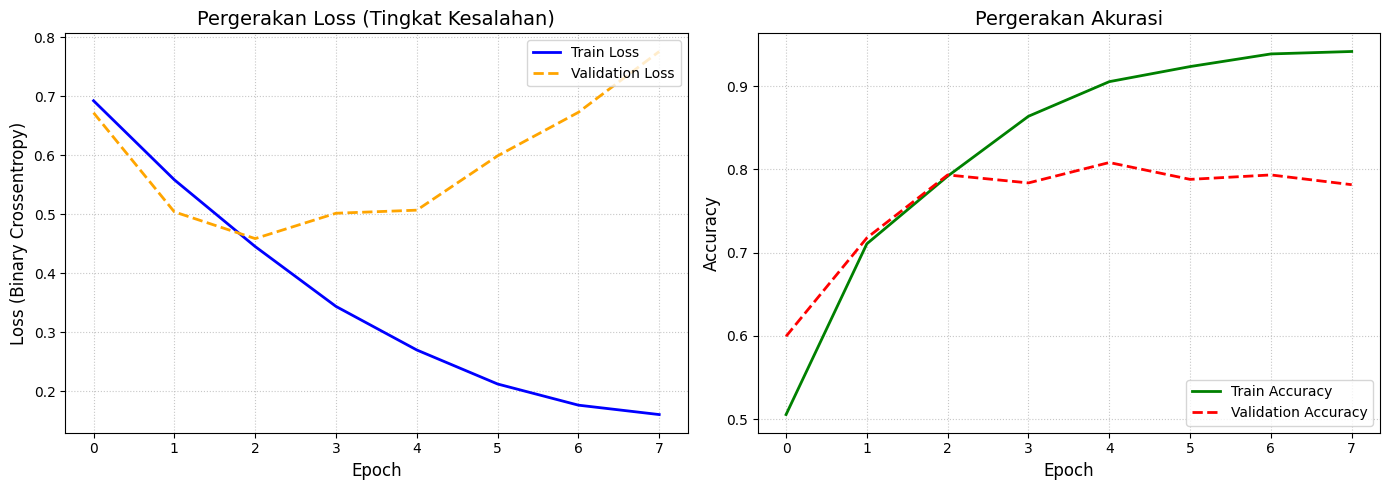

In [17]:
import matplotlib.pyplot as plt

# Mengatur ukuran kanvas grafik
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- 1. Grafik Pergerakan Loss ---
ax1.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2, linestyle='--')
ax1.set_title('Pergerakan Loss (Tingkat Kesalahan)', fontsize=14)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss (Binary Crossentropy)', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, linestyle=':', alpha=0.7)

# --- 2. Grafik Pergerakan Akurasi ---
ax2.plot(history.history['accuracy'], label='Train Accuracy', color='green', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2, linestyle='--')
ax2.set_title('Pergerakan Akurasi', fontsize=14)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(loc='lower right')
ax2.grid(True, linestyle=':', alpha=0.7)

# Menampilkan grafik
plt.tight_layout()
plt.show()

Sedang melakukan prediksi pada data testing...
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step

          CLASSIFICATION REPORT
                 precision    recall  f1-score   support

Tidak Cocok (0)       0.84      0.71      0.77       406
      Cocok (1)       0.76      0.87      0.81       423

       accuracy                           0.79       829
      macro avg       0.80      0.79      0.79       829
   weighted avg       0.80      0.79      0.79       829



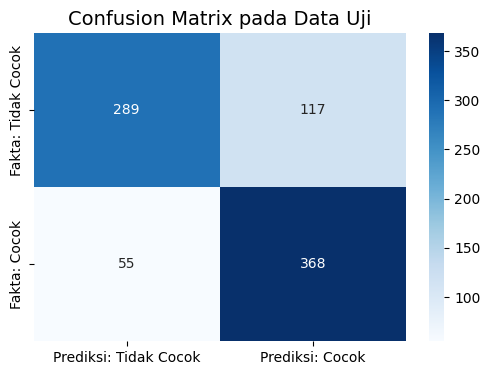

In [18]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Lakukan prediksi menggunakan data testing
print("Sedang melakukan prediksi pada data testing...")
y_pred_prob = model.predict([X_cv_test, X_job_test])

# 2. Ubah probabilitas menjadi label kelas (0 atau 1) dengan threshold 0.5
# Jika probabilitas > 0.5, maka True (1), jika tidak maka False (0)
y_pred_classes = (y_pred_prob > 0.5).astype(int).flatten()

# 3. Tampilkan Classification Report
print("\n" + "="*40)
print("          CLASSIFICATION REPORT")
print("="*40)
print(classification_report(y_test, y_pred_classes, target_names=['Tidak Cocok (0)', 'Cocok (1)']))

# 4. (Opsional) Tampilkan Confusion Matrix agar lebih visual
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prediksi: Tidak Cocok', 'Prediksi: Cocok'],
            yticklabels=['Fakta: Tidak Cocok', 'Fakta: Cocok'])
plt.title('Confusion Matrix pada Data Uji', fontsize=14)
plt.show()

In [16]:
# Menghitung kemiripan (Dot Product sering dipakai untuk mengukur similarity di neural network)
# similarity = Dot(axes=1, normalize=True, name="cosine_similarity")([cv_vector, job_vector])

# # Gabungkan menjadi satu model
# model = Model(inputs=[cv_input, job_input], outputs=similarity)

# model.compile(optimizer='adam', loss='mse', metrics=['mae'])
# model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cv_input            │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ job_input           │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_embedding    │ (None, 150, 64)   │    640,000 │ cv_input[0][0],   │
│ (Embedding)         │                   │            │ job_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_bilstm       │ (None, 128)       │     66,048 │ shared_embedding… │
│ (Bidirectional)     │                   │            │ shared_embedding… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cosine_similarity   │ (None, 1)         │          0 │ shared_bilstm[0]… │
│ (Dot)               │                   │            │ shared_bilstm[1]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 706,048 (2.69 MB)

 Trainable params: 706,048 (2.69 MB)

 Non-trainable params: 0 (0.00 B)

Total data Train (termasuk Validation nanti): 4693
Total data Test murni: 829


In [21]:
# 4. TRAINING MODEL
# Karena target kita asal jalan dulu, 5-10 epoch sudah cukup
# model.fit(
#     x=[X_cv_train, X_job_train],
#     y=labels,
#     epochs=5,
#     batch_size=32,
#     validation_split=0.2
# )

Epoch 1/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.2230 - mae: 0.3574 - val_loss: 0.5234 - val_mae: 0.7184
Epoch 2/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.1973 - mae: 0.3793 - val_loss: 0.6029 - val_mae: 0.7749
Epoch 3/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.1920 - mae: 0.3782 - val_loss: 0.6284 - val_mae: 0.7903
Epoch 4/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.1843 - mae: 0.3668 - val_loss: 0.6002 - val_mae: 0.7694
Epoch 5/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.1702 - mae: 0.3410 - val_loss: 0.5065 - val_mae: 0.6994


In [20]:
import pickle

# Tentukan path penyimpanan di Google Drive kamu
# Menggunakan folder yang sama dengan tempat dataset kamu berada

# save_path = '/content/drive/MyDrive/Dataset_codingcamp_loker/'
save_path = './model_hasil/'

# 1. Menyimpan Model Keras
# Menggunakan format .keras yang merupakan standar terbaru dan terefisien dari TensorFlow
model.save(save_path + 'model_rekomendasi_loker.keras')

# 2. Menyimpan Tokenizer menggunakan Pickle
with open(save_path + 'tokenizer_loker.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

print("Model dan Tokenizer berhasil disimpan dengan aman di Google Drive!")

Model dan Tokenizer berhasil disimpan dengan aman di Google Drive!


In [22]:
# print("\n=== Evaluasi pada Data Test Murni ===")
# eval_results = model.evaluate(x=[X_cv_test, X_job_test], y=y_test)

# print(f"Loss pada Data Test: {eval_results[0]:.4f}")
# print(f"MAE pada Data Test: {eval_results[1]:.4f}")


=== Evaluasi pada Data Test Murni ===
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2913 - mae: 0.4802
Loss pada Data Test: 0.2913
MAE pada Data Test: 0.4802


In [22]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Asumsi:
# 1. 'model' sudah di-load atau masih ada di memori.
# 2. 'tokenizer' sudah di-load.
# 3. 'df_raw' adalah dataframe aslimu yang berisi semua lowongan.

# 1. Teks CV dari User (Bisa didapat dari input form)
text_cv_user = "Saya seorang fresh graduate jurusan sistem informasi. Memiliki kemampuan analisis yang baik, menguasai SQL, dan paham SDLC. Saya mencari pekerjaan di bidang analisis sistem."

# 2. Siapkan semua teks lowongan kerja dari database (menggunakan text_gabungan)
semua_teks_lowongan = df['text_gabungan'].tolist()
jumlah_lowongan = len(semua_teks_lowongan)

# 3. Gandakan teks CV user agar jumlahnya sama dengan jumlah lowongan
# Ini menciptakan pasangan (CV User, Job 1), (CV User, Job 2), dst...
teks_cv_digandakan = [text_cv_user] * jumlah_lowongan

# 4. Tokenisasi dan Padding
seq_cv_infer = pad_sequences(tokenizer.texts_to_sequences(teks_cv_digandakan), maxlen=MAX_LEN, padding='post')
seq_job_infer = pad_sequences(tokenizer.texts_to_sequences(semua_teks_lowongan), maxlen=MAX_LEN, padding='post')

# 5. Lakukan Prediksi (Mencari skor kecocokan untuk semua pasangan)
print("Sedang mencocokkan CV dengan semua lowongan...")
skor_prediksi = model.predict([seq_cv_infer, seq_job_infer])

# Ratakan array skor dari bentuk 2D misal [[0.9], [0.1]] menjadi 1D [0.9, 0.1]
skor_prediksi = skor_prediksi.flatten()

# 6. Mengurutkan hasil dari skor tertinggi ke terendah
# argsort mengembalikan index. '[::-1]' digunakan untuk membalik urutan agar yang terbesar di awal.
index_terbaik = np.argsort(skor_prediksi)[::-1]

# 7. Tampilkan Top 5 Rekomendasi Teratas
top_n = 5
print(f"\n=== TOP {top_n} REKOMENDASI LOWONGAN KERJA ===")

for i in range(top_n):
    idx = index_terbaik[i]
    skor = skor_prediksi[idx]

    # Hanya tampilkan jika skornya di atas threshold (misal > 0.5)
    if skor > 0.5:
        print(f"\nRekomendasi #{i+1} (Skor Kecocokan: {skor:.4f})")
        # Mengambil data dari raw dataframe berdasarkan index
        print(f"Judul    : {df.loc[idx, 'Judul']}")
        print(f"Perusahaan: {df.loc[idx, 'Industri']}") # Ganti dengan kolom yang sesuai
        print(f"Lokasi   : {df.loc[idx, 'Kota']}")
    else:
        print(f"\nRekomendasi #{i+1}: Tidak ada lagi lowongan yang dianggap cocok (Skor < 0.5)")
        break

Sedang mencocokkan CV dengan semua lowongan...
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step

=== TOP 5 REKOMENDASI LOWONGAN KERJA ===

Rekomendasi #1 (Skor Kecocokan: 0.9079)
Judul    : Software Engineer
Perusahaan: Information Technology and Services
Lokasi   : Surabaya

Rekomendasi #2 (Skor Kecocokan: 0.8862)
Judul    : Video Editor (CapCut)
Perusahaan: Retail
Lokasi   : Jakarta Barat

Rekomendasi #3 (Skor Kecocokan: 0.8412)
Judul    : AI Engineer
Perusahaan: Computer & Network Security
Lokasi   : Jakarta Utara

Rekomendasi #4 (Skor Kecocokan: 0.8335)
Judul    : Short Video Editor
Perusahaan: Media Production
Lokasi   : Jakarta Timur

Rekomendasi #5 (Skor Kecocokan: 0.8332)
Judul    : [INTERN] Backend Developer
Perusahaan: Information Technology and Services
Lokasi   : Surabaya
